# 2016 BCHH infrasound relative-calibration check — reconciled-time workflow

Purpose: test whether the relative gains of the colocated BCHH infrasound channels were stable before and after the 1 September 2016 AMOS-6 explosion.

This version deliberately separates three questions: **is T0 trustworthy?**, **is there a coherent pressure signal?**, and only then **are the relative gains stable?** Raw-count ratios are never computed from the unprocessed 270-s extraction window. Counts are linearly detrended, demeaned, tapered and zero-phase high-pass filtered at 0.1 Hz first; ratios are computed only inside an inspected coherent signal window.

The hand-edited EnhancedSDSClient import, SDS/StationXML paths and BCHH DD1/DD2/DD3 channel IDs are intentionally preserved.


In [1]:
from pathlib import Path
import sqlite3
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import UTCDateTime, Stream, read_inventory
from flovopy.enhanced.sdsclient import EnhancedSDSClient

# Locate repository root whether Jupyter starts there or in 04_event_catalog/.
here = Path.cwd().resolve()
ROOT = next(
    (p for p in [here, *here.parents]
     if (p / "data").exists() and (p / "pyproject.toml").exists()),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not locate repository root")

DB = ROOT / "data/processed/ksc_rockets.sqlite"
SDS_ROOT = Path("/Volumes/classdata/remastered/SDS_KSC")
XML = Path("/Volumes/classdata/KSC/station_metadata/KSC.xml")

PRESSURE_IDS = [
    "1R.BCHH.10.DD1",
    "1R.BCHH.10.DD2",
    "1R.BCHH.10.DD3",
]

for label, path in {"Database": DB, "SDS": SDS_ROOT, "StationXML": XML}.items():
    print(f"{label}: {path}")
    if not path.exists():
        raise FileNotFoundError(f"{label} not found: {path}")

sds = EnhancedSDSClient(str(SDS_ROOT))
inv = read_inventory(str(XML))
print("Pressure channels:", PRESSURE_IDS)


Database: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/KSCRocketSeismology_event_catalog_workflow_v5/data/processed/ksc_rockets.sqlite
SDS: /Volumes/classdata/remastered/SDS_KSC
StationXML: /Volumes/classdata/KSC/station_metadata/KSC.xml
Pressure channels: ['1R.BCHH.10.DD1', '1R.BCHH.10.DD2', '1R.BCHH.10.DD3']


## 1. Query reconciled event times and provenance

For ordinary launches used in the calibration comparison, prefer events supported by at least two **actual-event-time** sources. Scheduled launch times are provenance only and are not treated as physical waveform events.


In [2]:
START = "2016-07-01T00:00:00Z"
END   = "2016-10-01T00:00:00Z"
RECON = ROOT / "data/processed/event_reconciliation.csv"
SOURCES = ROOT / "data/processed/event_time_sources.csv"

if RECON.exists():
    all_events = pd.read_csv(RECON, dtype=str).fillna("")
    all_events["event_time"] = pd.to_datetime(
        all_events["event_time_utc"], format="ISO8601", utc=True
    )
    all_events["source_count"] = pd.to_numeric(
        all_events.get("source_count", 0), errors="coerce"
    ).fillna(0).astype(int)
    all_events["time_spread_s"] = pd.to_numeric(
        all_events.get("time_spread_s", np.nan), errors="coerce"
    )
    events = all_events[
        (all_events.event_time >= pd.Timestamp(START))
        & (all_events.event_time < pd.Timestamp(END))
    ].copy()
else:
    with sqlite3.connect(DB) as con:
        events = pd.read_sql_query(
            """
            SELECT event_id,event_type,event_time_utc,mission,vehicle,pad,notes
            FROM events
            WHERE event_time_utc >= ? AND event_time_utc < ?
            ORDER BY event_time_utc
            """,
            con,
            params=(START, END),
        )
    events["event_time"] = pd.to_datetime(
        events["event_time_utc"], format="ISO8601", utc=True
    )
    events["source_count"] = 0
    events["time_spread_s"] = np.nan

# Load provenance once, under the name used by the rest of the notebook.
if SOURCES.exists():
    time_sources = pd.read_csv(SOURCES, dtype=str).fillna("")
    time_sources = time_sources[time_sources.event_id.isin(events.event_id)].copy()
else:
    time_sources = pd.DataFrame()

print(f"Loaded {len(events)} reconciled events between {START} and {END}")
print(f"Loaded {len(time_sources)} matching event-time source records")

cols = [
    c for c in [
        "event_id", "event_type", "event_time_utc", "mission", "vehicle", "pad",
        "source_count", "time_spread_s", "time_conflict"
    ]
    if c in events.columns
]
display(events.sort_values("event_time")[cols])


Loaded 8 reconciled events between 2016-07-01T00:00:00Z and 2016-10-01T00:00:00Z
Loaded 19 matching event-time source records


,event_id,event_type,event_time_utc,mission,vehicle,pad,source_count,time_spread_s,time_conflict
13,ksc-ece933e3a11b,static_fire,2016-07-16T04:45:00Z,Falcon 9 1.2,,40,1,0.0,False
14,ksc-ecc6d9e04f0e,orbital_launch,2016-07-18T04:45:29Z,Falcon 9 1.2|F9-27 Dragon/CRS-9,,40,3,0.0,False
15,ksc-74a3bdfdf731,orbital_launch,2016-07-28T12:37:00Z,Atlas V 421|AV065 NROL-61,,41,3,0.0,False
16,ksc-846e0481c2e9,static_fire,2016-08-10T05:26:00Z,Falcon 9 1.2,,40,1,0.0,False
17,ksc-bb9fcefb0a9c,orbital_launch,2016-08-14T05:26:00Z,Falcon 9 1.2|F9-28 JCSAT 16,,40,3,0.0,False
18,ksc-4bf555bb8599,orbital_launch,2016-08-19T04:52:00Z,Delta IV |AFSPC-6,,37B,3,0.0,False
19,ksc-d79e38ae7638,pad_explosion,2016-09-01T13:07:15Z,Falcon 9,,40,2,15.0,False
20,ksc-db1cc89a1aaf,orbital_launch,2016-09-08T23:05:00Z,Atlas V 411|AV067 OSIRIS-Rex,,41,3,0.0,False


**T0 acceptance for the calibration comparison:** JCSAT-16, AFSPC-6 and OSIRIS-REx should each have at least two actual-time sources with negligible spread. AMOS-6 is treated separately as an extreme-amplitude survival/nonlinearity test. If this provenance table does not show that, stop before interpreting calibration ratios.


In [3]:
# Core events for the 2016 BCHH relative-calibration check.
core_mask = events["mission"].astype(str).str.contains(
    "JCSAT|AFSPC|OSIRIS|AMOS", case=False, regex=True, na=False
)
core_events = events.loc[core_mask].copy()
core_ids = set(core_events["event_id"])

display(core_events[[
    c for c in [
        "event_id", "event_type", "event_time_utc", "mission", "vehicle", "pad",
        "source_count", "time_spread_s", "time_conflict"
    ]
    if c in core_events.columns
]].sort_values("event_time_utc"))

if not time_sources.empty:
    provenance_cols = [
        c for c in [
            "event_id", "source", "source_name", "time_utc", "precision",
            "time_definition", "time_role", "source_event_id", "notes"
        ]
        if c in time_sources.columns
    ]
    display(
        time_sources[time_sources.event_id.isin(core_ids)][provenance_cols]
        .sort_values(["event_id", "time_utc"])
    )
else:
    print("No event_time_sources.csv provenance table was found.")


,event_id,event_type,event_time_utc,mission,vehicle,pad,source_count,time_spread_s,time_conflict
17,ksc-bb9fcefb0a9c,orbital_launch,2016-08-14T05:26:00Z,Falcon 9 1.2|F9-28 JCSAT 16,,40,3,0.0,False
18,ksc-4bf555bb8599,orbital_launch,2016-08-19T04:52:00Z,Delta IV |AFSPC-6,,37B,3,0.0,False
20,ksc-db1cc89a1aaf,orbital_launch,2016-09-08T23:05:00Z,Atlas V 411|AV067 OSIRIS-Rex,,41,3,0.0,False


,event_id,source_name,time_utc,precision,time_definition,time_role,source_event_id,notes
42,ksc-4bf555bb8599,manual_excel,2016-08-19T04:52:00Z,minute,manual_compilation_liftoff_or_event_time,actual_event_time,,
43,ksc-4bf555bb8599,launch_library_2,2016-08-19T04:52:00Z,,LL2 NET/T-0,actual_event_time,b874f013-5a64-407d-8ca4-c35835c4dde2,
44,ksc-4bf555bb8599,gcat,2016-08-19T04:52:00Z,minute,GCAT Launch_Date (UTC; first motion),actual_event_time,2016-052,-
39,ksc-bb9fcefb0a9c,manual_excel,2016-08-14T05:26:00Z,minute,manual_compilation_liftoff_or_event_time,actual_event_time,,
40,ksc-bb9fcefb0a9c,launch_library_2,2016-08-14T05:26:00Z,,LL2 NET/T-0,actual_event_time,42af1017-49f4-41ec-97d6-0c3520643fc8,
41,ksc-bb9fcefb0a9c,gcat,2016-08-14T05:26:00Z,minute,GCAT Launch_Date (UTC; first motion),actual_event_time,2016-050,-
47,ksc-db1cc89a1aaf,manual_excel,2016-09-08T23:05:00Z,minute,manual_compilation_liftoff_or_event_time,actual_event_time,,
48,ksc-db1cc89a1aaf,launch_library_2,2016-09-08T23:05:00Z,,LL2 NET/T-0,actual_event_time,0bcc6850-4c51-4b08-aa19-0b3753351b9b,
49,ksc-db1cc89a1aaf,gcat,2016-09-08T23:05:00Z,minute,GCAT Launch_Date (UTC; first motion),actual_event_time,2016-055,-


## 2. Read the three BCHH pressure channels

Use explicit trace IDs rather than wildcard discovery. The broad extraction window is only for diagnostics and signal finding.


In [4]:
PRE_S = 30
POST_S = 240

def read_event(row):
    t0 = UTCDateTime(row["event_time_utc"])
    return sds.read(
        starttime=t0-PRE_S,
        endtime=t0+POST_S,
        trace_ids=PRESSURE_IDS,
        skip_low_rate_channels=False,
        merge=None, trim=True, daywise=False,
        postprocess=False, final_smart_merge=False, verbose=False,
    )

event_streams = {}
availability_rows = []
for _, row in events.iterrows():
    try:
        st = read_event(row)
        event_streams[row.event_id] = st
        print(row.event_time_utc, row.mission, sorted({tr.id for tr in st}))
        for tr in st:
            availability_rows.append({
                "event_id": row.event_id, "mission": row.mission, "seed_id": tr.id,
                "sampling_rate": float(tr.stats.sampling_rate), "npts": int(tr.stats.npts),
                "starttime": str(tr.stats.starttime), "endtime": str(tr.stats.endtime),
            })
    except Exception as exc:
        print(row.event_time_utc, row.mission, "READ FAILED:", exc)

availability = pd.DataFrame(availability_rows)
availability


2016-07-16T04:45:00Z Falcon 9 1.2 []
2016-07-18T04:45:29Z Falcon 9 1.2|F9-27 Dragon/CRS-9 []
2016-07-28T12:37:00Z Atlas V 421|AV065 NROL-61 []
2016-08-10T05:26:00Z Falcon 9 1.2 []
2016-08-14T05:26:00Z Falcon 9 1.2|F9-28 JCSAT 16 ['1R.BCHH.10.DD1', '1R.BCHH.10.DD2', '1R.BCHH.10.DD3']
2016-08-19T04:52:00Z Delta IV  |AFSPC-6 ['1R.BCHH.10.DD1', '1R.BCHH.10.DD2', '1R.BCHH.10.DD3']
2016-09-01T13:07:15Z Falcon 9 ['1R.BCHH.10.DD1', '1R.BCHH.10.DD2', '1R.BCHH.10.DD3']
2016-09-08T23:05:00Z Atlas V 411|AV067 OSIRIS-Rex ['1R.BCHH.10.DD1', '1R.BCHH.10.DD2', '1R.BCHH.10.DD3']


,event_id,mission,seed_id,sampling_rate,npts,starttime,endtime
0,ksc-bb9fcefb0a9c,Falcon 9 1.2|F9-28 JCSAT 16,1R.BCHH.10.DD1,250.0,67501,2016-08-14T05:25:30.000000Z,2016-08-14T05:30:00.000000Z
1,ksc-bb9fcefb0a9c,Falcon 9 1.2|F9-28 JCSAT 16,1R.BCHH.10.DD2,250.0,67501,2016-08-14T05:25:30.000000Z,2016-08-14T05:30:00.000000Z
2,ksc-bb9fcefb0a9c,Falcon 9 1.2|F9-28 JCSAT 16,1R.BCHH.10.DD3,250.0,67501,2016-08-14T05:25:30.000000Z,2016-08-14T05:30:00.000000Z
3,ksc-4bf555bb8599,Delta IV |AFSPC-6,1R.BCHH.10.DD1,250.0,67501,2016-08-19T04:51:30.000000Z,2016-08-19T04:56:00.000000Z
4,ksc-4bf555bb8599,Delta IV |AFSPC-6,1R.BCHH.10.DD2,250.0,67501,2016-08-19T04:51:30.000000Z,2016-08-19T04:56:00.000000Z
5,ksc-4bf555bb8599,Delta IV |AFSPC-6,1R.BCHH.10.DD3,250.0,67501,2016-08-19T04:51:30.000000Z,2016-08-19T04:56:00.000000Z
6,ksc-d79e38ae7638,Falcon 9,1R.BCHH.10.DD1,250.0,67501,2016-09-01T13:06:45.000000Z,2016-09-01T13:11:15.000000Z
7,ksc-d79e38ae7638,Falcon 9,1R.BCHH.10.DD2,250.0,67501,2016-09-01T13:06:45.000000Z,2016-09-01T13:11:15.000000Z
8,ksc-d79e38ae7638,Falcon 9,1R.BCHH.10.DD3,250.0,67501,2016-09-01T13:06:45.000000Z,2016-09-01T13:11:15.000000Z
9,ksc-db1cc89a1aaf,Atlas V 411|AV067 OSIRIS-Rex,1R.BCHH.10.DD1,250.0,67501,2016-09-08T23:04:30.000000Z,2016-09-08T23:09:00.000000Z


## 3. Preprocess raw counts consistently

Every raw-count trace gets the same sequence: **linear detrend → demean → cosine taper → 0.1-Hz high-pass**. The original streams remain unchanged.


In [5]:
HIGHPASS_HZ = 0.1
FILTER_CORNERS = 4
ZEROPHASE = True
TAPER_FRACTION = 0.05

def preprocess_counts(st):
    out = Stream()
    for tr in st:
        if tr.id not in PRESSURE_IDS:
            continue
        x = tr.copy()
        x.detrend("linear")
        x.detrend("demean")
        x.taper(max_percentage=TAPER_FRACTION, type="cosine")
        x.filter("highpass", freq=HIGHPASS_HZ, corners=FILTER_CORNERS, zerophase=ZEROPHASE)
        x.stats.units = "counts (detrended, HP 0.1 Hz)"
        out.append(x)
    return out

filtered_streams = {eid: preprocess_counts(st) for eid, st in event_streams.items()}


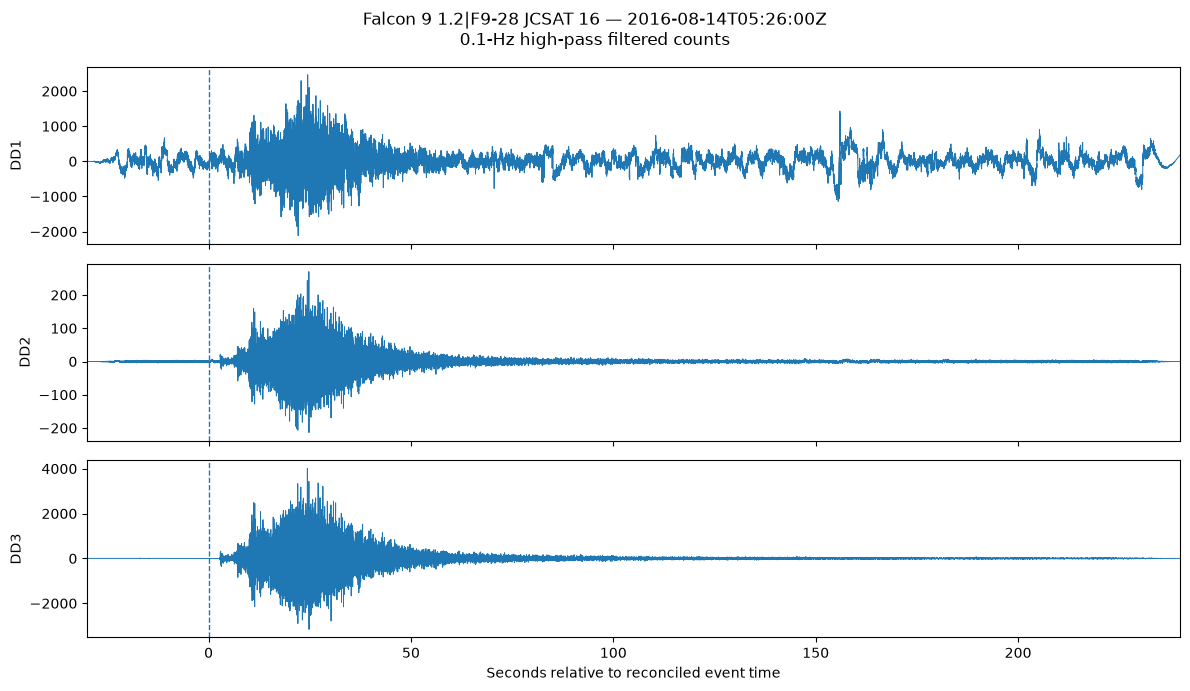

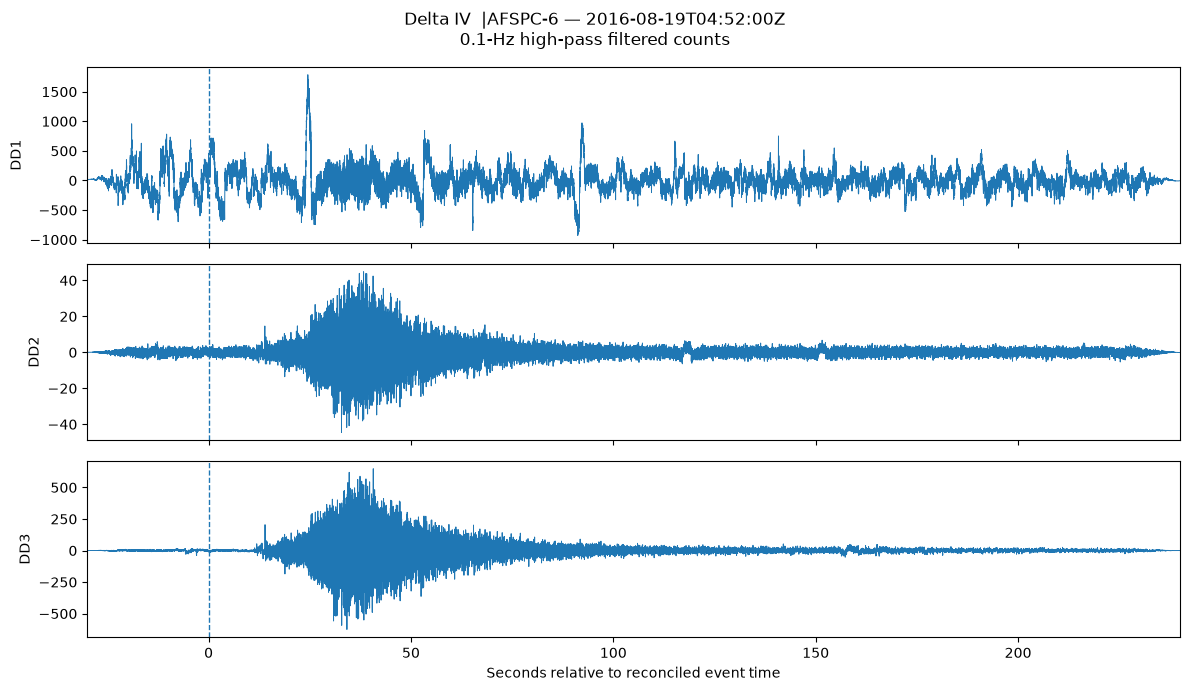

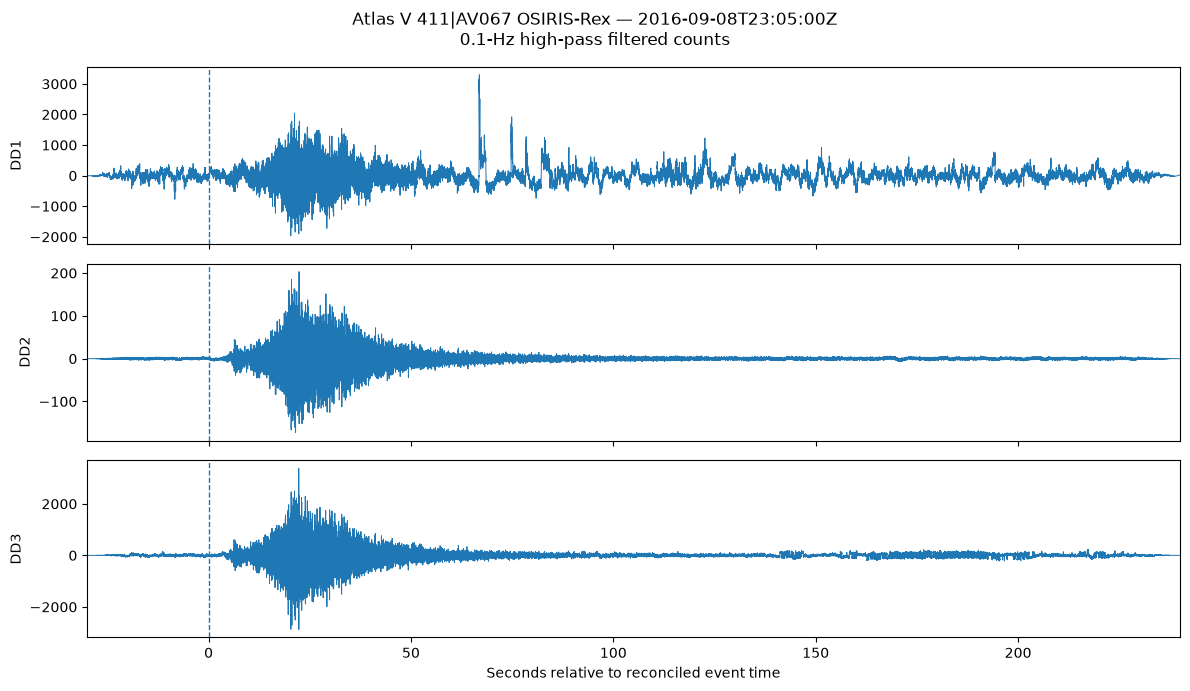

In [6]:
def plot_event_stream(event_id, streams=filtered_streams, xlim=(-30, 240)):
    row = events.set_index("event_id").loc[event_id]
    t0 = UTCDateTime(row.event_time_utc)
    st = streams[event_id]
    fig, axes = plt.subplots(len(PRESSURE_IDS), 1, figsize=(12, 7), sharex=True)
    for ax, seed_id in zip(axes, PRESSURE_IDS):
        matches = [tr for tr in st if tr.id == seed_id]
        if not matches:
            ax.text(0.5, 0.5, f"{seed_id}: missing", transform=ax.transAxes, ha="center")
            continue
        tr = matches[0]
        tt = np.arange(tr.stats.npts)/tr.stats.sampling_rate + float(tr.stats.starttime-t0)
        ax.plot(tt, tr.data, linewidth=0.7)
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_ylabel(seed_id.split(".")[-1])
        ax.set_xlim(*xlim)
    axes[-1].set_xlabel("Seconds relative to reconciled event time")
    fig.suptitle(f"{row.mission} — {row.event_time_utc}\n0.1-Hz high-pass filtered counts")
    fig.tight_layout()
    plt.show()

for eid in events.loc[core_mask, "event_id"]:
    if eid in filtered_streams:
        plot_event_stream(eid)


## 4. Find a coherent signal window

The detector requires both elevated amplitude relative to a pre-event noise window and positive inter-channel correlation. It is intentionally conservative. **Always inspect the plots.** `MANUAL_WINDOWS` can override the automatic result for any event after visual review.


### Windowing strategy for relative calibration

DD1 is consistently the noisiest BCHH pressure channel and is **especially poor during the Delta IV / AFSPC-6 launch**. For JCSAT-16 and OSIRIS-REx, DD1 can still be compared over a tightly restricted interval. Automatic onset is therefore determined from the more robust **DD2 and DD3** channels, and ordinary-launch calibration uses the **first 50 s after both DD2 and DD3 cross the SNR threshold**. DD2/DD3 is the primary relative-calibration pair; comparisons involving DD1 are secondary QC, and DD1 is not used for the Delta IV calibration inference.

AMOS-6 remains a separate extreme-event/stress test rather than an ordinary launch calibration point. The StationXML gives all three channels the same nominal 0.5-inch infraBSU response, so response-corrected ratios do not independently validate relative sensor sensitivity.


In [7]:
# Calibration-window selection.
#
# Empirical observation from the diagnostic plots:
# - DD1 is the noisiest channel throughout, and is especially poor for the Delta IV / AFSPC-6 launch.
# - For the other ordinary launches DD1 is usable if we restrict the comparison to the
#   first ~50 s of the launch signal.
# - DD2 and DD3 are therefore used as the robust pair for automatic onset detection.
# - Correlation is QC only; it is NOT a signal-existence gate.
#
# StationXML assigns the same nominal 0.5-inch infraBSU response to DD1/DD2/DD3, so
# response removal cannot establish their true relative sensitivities.

NOISE_WINDOW = (-25.0, -5.0)
SEARCH_WINDOW = (0.0, 180.0)
ENV_WINDOW_S = 1.0
ONSET_SNR = 5.0
CAL_WINDOW_LENGTH_S = 50.0

# Manual overrides are seconds relative to catalog T0.
# Use these after visual inspection if an automatic onset is not satisfactory.
MANUAL_WINDOWS = {
    # "JCSAT": (start_s, start_s + 50.0),
    # "AFSPC": (start_s, start_s + 50.0),
    # "OSIRIS": (start_s, start_s + 50.0),
    # "AMOS": (start_s, end_s),   # explosion treated separately
}

ROBUST_IDS = ["1R.BCHH.10.DD2", "1R.BCHH.10.DD3"]

def rolling_rms(x, n):
    x = np.asarray(x, dtype=float)
    if n <= 1:
        return np.abs(x)
    return np.sqrt(
        pd.Series(x*x).rolling(
            n, center=True, min_periods=max(1, n//3)
        ).mean().to_numpy()
    )

def manual_window_for(row):
    text = f"{row.get('mission','')} {row.get('event_type','')} {row.get('notes','')}".lower()
    for key, win in MANUAL_WINDOWS.items():
        if key.lower() in text or key == row["event_id"]:
            return tuple(win)
    return None

def channel_snr(tr, t0):
    sr = float(tr.stats.sampling_rate)
    t = np.arange(tr.stats.npts)/sr + float(tr.stats.starttime - t0)
    x = np.asarray(tr.data, dtype=float)
    env = rolling_rms(x, max(1, int(round(ENV_WINDOW_S*sr))))
    nm = (t >= NOISE_WINDOW[0]) & (t <= NOISE_WINDOW[1])
    noise = np.nanmedian(env[nm]) if np.any(nm) else np.nan
    snr = env/noise if np.isfinite(noise) and noise > 0 else np.full_like(env, np.nan)
    return t, x, env, snr

signal_rows=[]
signal_windows={}

for _, row in events.sort_values("event_time").iterrows():
    eid=row["event_id"]
    st=filtered_streams.get(eid)
    if st is None or len(st) < 2:
        signal_rows.append(dict(
            event_id=eid, event_time_utc=row.event_time_utc, mission=row.mission,
            event_type=row.event_type, signal_found=False, reason="fewer than two channels"
        ))
        continue

    t0=UTCDateTime(row.event_time_utc)
    by_id={tr.id: tr for tr in st}
    info={}
    for tid,tr in by_id.items():
        t,x,env,snr=channel_snr(tr,t0)
        sm=(t>=SEARCH_WINDOW[0])&(t<=SEARCH_WINDOW[1])
        peak=float(np.nanmax(snr[sm])) if np.any(sm) else np.nan
        info[tid]=dict(t=t,x=x,env=env,snr=snr,peak_snr=peak)

    manual=manual_window_for(row)
    onset_candidates=[]
    for tid in ROBUST_IDS:
        d=info.get(tid)
        if d is None:
            continue
        m=(d["t"]>=SEARCH_WINDOW[0])&(d["t"]<=SEARCH_WINDOW[1])&(d["snr"]>=ONSET_SNR)
        if np.any(m):
            onset_candidates.append(float(d["t"][np.flatnonzero(m)[0]]))

    # Require DD2 and DD3 for an automatic ordinary-launch window.
    auto=None
    if len(onset_candidates)==2:
        onset=max(onset_candidates)  # both robust channels have crossed threshold
        auto=(onset, min(onset+CAL_WINDOW_LENGTH_S, SEARCH_WINDOW[1]))

    # AMOS-6 is not an ordinary launch calibration window. Keep an explicit/manual
    # window if supplied; otherwise use the automatic 50-s window only for plotting/QC.
    chosen=manual if manual is not None else auto
    if chosen is not None:
        signal_windows[eid]=chosen

    # Zero-lag pair correlations over the chosen window are diagnostic only.
    corrs=[]
    if chosen is not None:
        tids=list(info)
        for a_i in range(len(tids)):
            for b_i in range(a_i+1,len(tids)):
                a,b=info[tids[a_i]],info[tids[b_i]]
                ma=(a["t"]>=chosen[0])&(a["t"]<=chosen[1])
                mb=(b["t"]>=chosen[0])&(b["t"]<=chosen[1])
                xa,xb=a["x"][ma],b["x"][mb]
                n=min(len(xa),len(xb))
                if n>10 and np.std(xa[:n])>0 and np.std(xb[:n])>0:
                    corrs.append(abs(float(np.corrcoef(xa[:n],xb[:n])[0,1])))

    rec=dict(
        event_id=eid, event_time_utc=row.event_time_utc, mission=row.mission,
        event_type=row.event_type, source_count=row.source_count,
        time_spread_s=row.time_spread_s,
        signal_found=chosen is not None,
        signal_start_s=chosen[0] if chosen else np.nan,
        signal_end_s=chosen[1] if chosen else np.nan,
        window_source="manual" if manual is not None else ("DD2_DD3_SNR_onset+50s" if auto else "none"),
        max_abs_corr=max(corrs) if corrs else np.nan,
    )
    for tid,d in info.items():
        rec[f"{tid}_peak_snr"]=d["peak_snr"]
    signal_rows.append(rec)

signal_summary=pd.DataFrame(signal_rows)
display(signal_summary)


,event_id,event_time_utc,mission,event_type,signal_found,reason,source_count,time_spread_s,signal_start_s,signal_end_s,window_source,max_abs_corr,1R.BCHH.10.DD1_peak_snr,1R.BCHH.10.DD2_peak_snr,1R.BCHH.10.DD3_peak_snr
0,ksc-ece933e3a11b,2016-07-16T04:45:00Z,Falcon 9 1.2,static_fire,False,fewer than two channels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ksc-ecc6d9e04f0e,2016-07-18T04:45:29Z,Falcon 9 1.2|F9-27 Dragon/CRS-9,orbital_launch,False,fewer than two channels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ksc-74a3bdfdf731,2016-07-28T12:37:00Z,Atlas V 421|AV065 NROL-61,orbital_launch,False,fewer than two channels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ksc-846e0481c2e9,2016-08-10T05:26:00Z,Falcon 9 1.2,static_fire,False,fewer than two channels,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ksc-bb9fcefb0a9c,2016-08-14T05:26:00Z,Falcon 9 1.2|F9-28 JCSAT 16,orbital_launch,True,NaN,3.0,0.0,2.548,52.548,DD2_DD3_SNR_onset+50s,0.129345,4.920400,65.184615,969.589806
5,ksc-4bf555bb8599,2016-08-19T04:52:00Z,Delta IV |AFSPC-6,orbital_launch,True,NaN,3.0,0.0,24.720,74.720,DD2_DD3_SNR_onset+50s,0.026982,6.606623,13.324462,73.335785
6,ksc-d79e38ae7638,2016-09-01T13:07:15Z,Falcon 9,pad_explosion,True,NaN,2.0,15.0,1.244,51.244,DD2_DD3_SNR_onset+50s,0.834122,21.735890,155.666502,118.544280
7,ksc-db1cc89a1aaf,2016-09-08T23:05:00Z,Atlas V 411|AV067 OSIRIS-Rex,orbital_launch,True,NaN,3.0,0.0,5.740,55.740,DD2_DD3_SNR_onset+50s,0.075615,11.063810,55.585271,40.116791


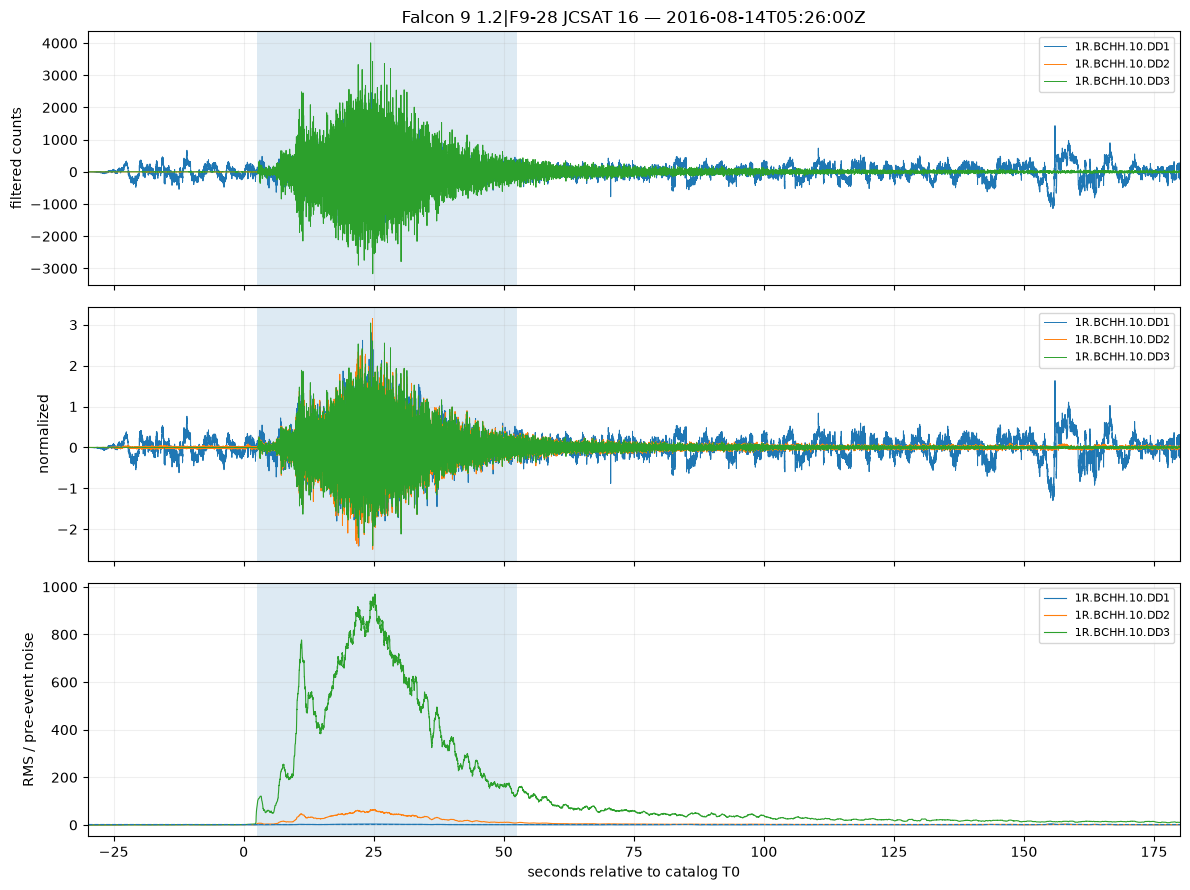

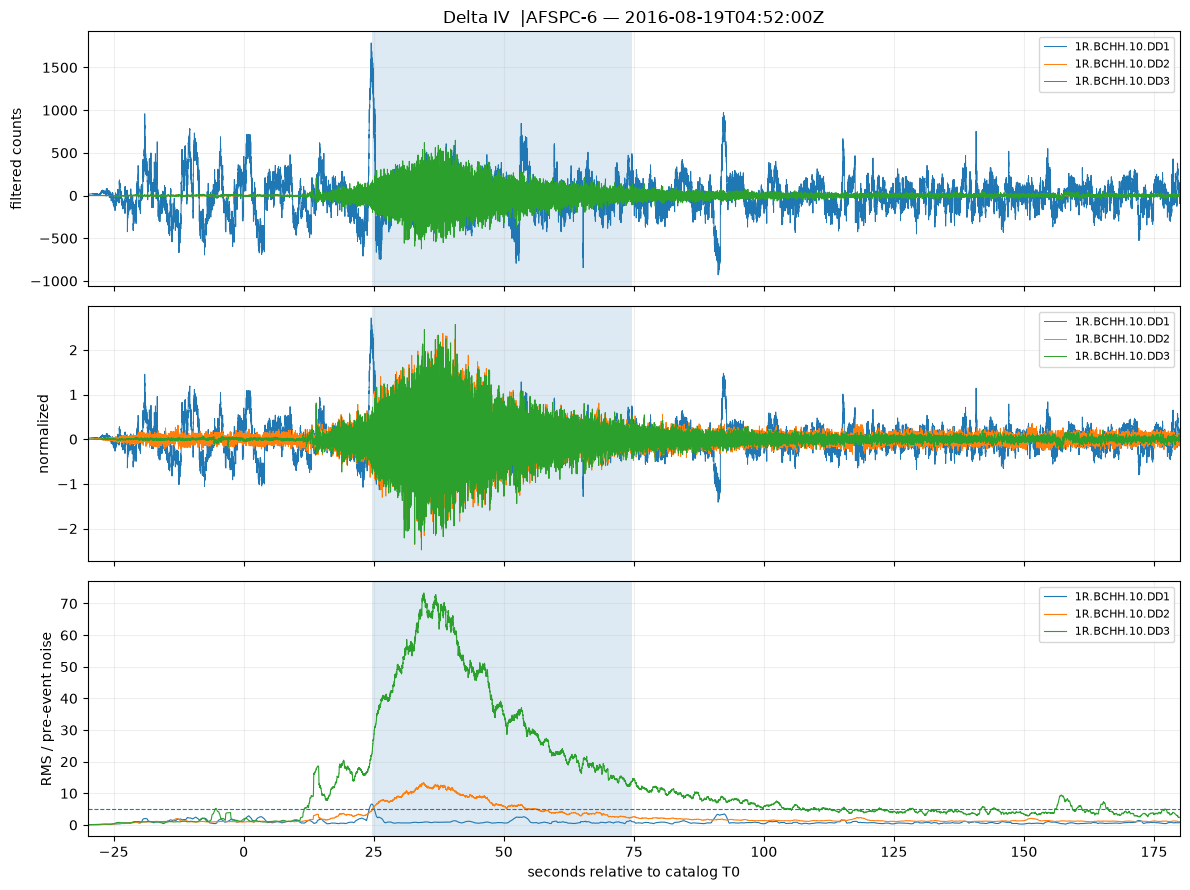

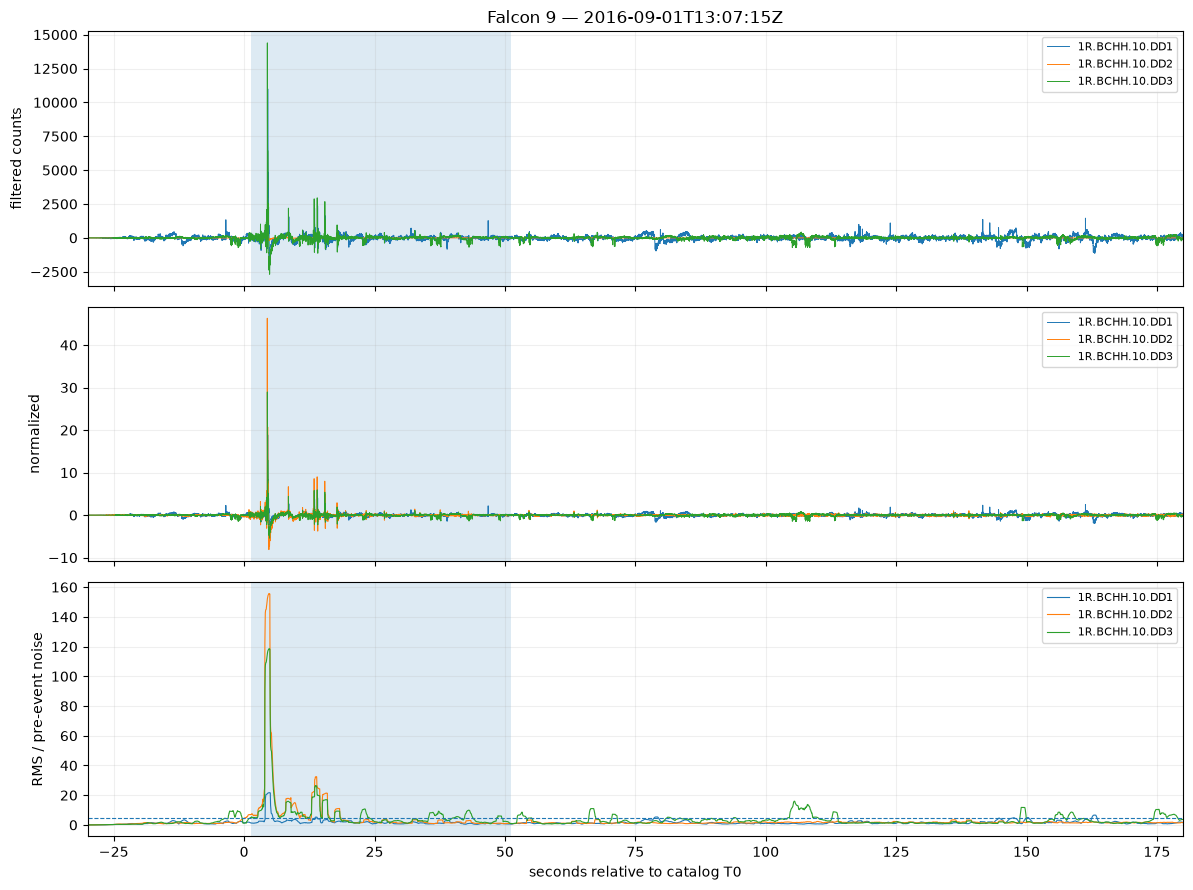

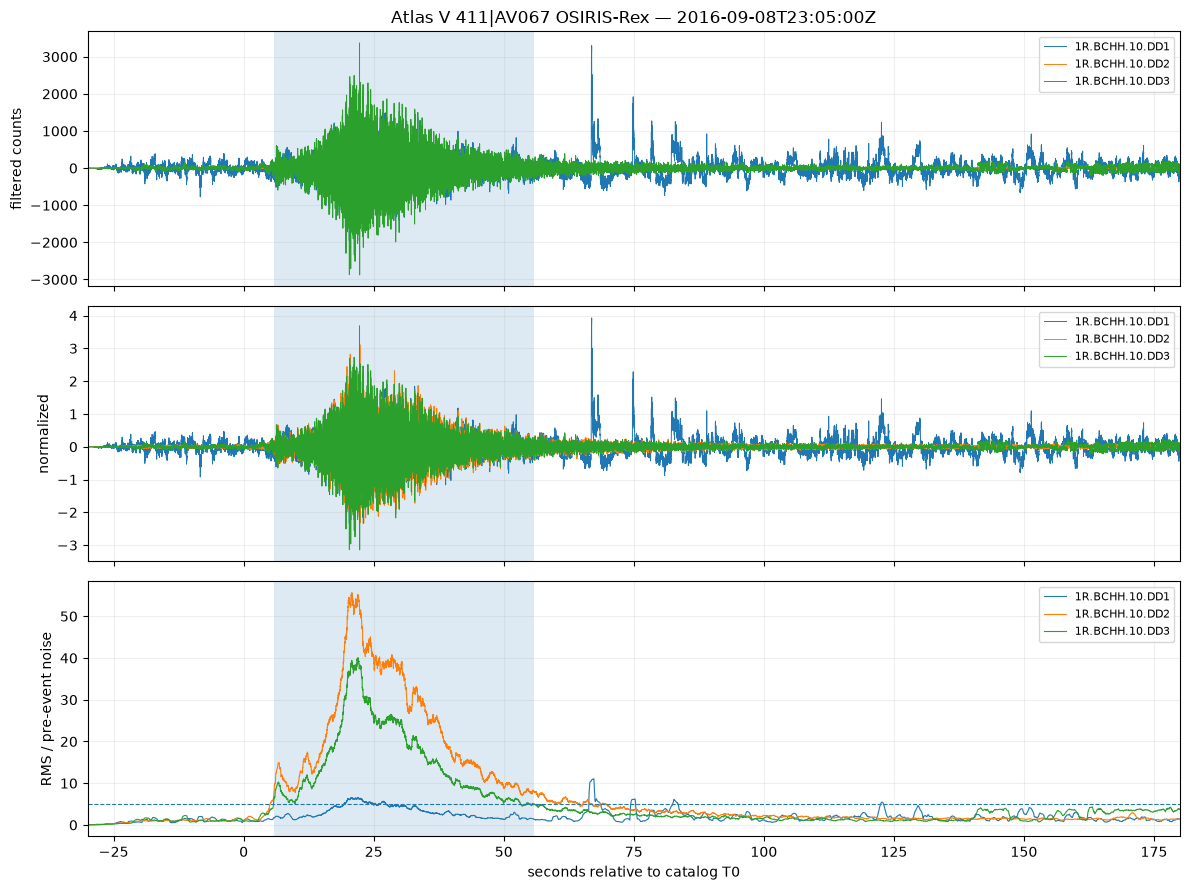

In [8]:
# Three-panel diagnostics. Inspect these before trusting any relative-gain number.
def plot_signal_diagnostic(event_id, xlim=(-30, 180)):
    row=events.set_index("event_id").loc[event_id]
    st=filtered_streams.get(event_id)
    if st is None or len(st)==0:
        return
    t0=UTCDateTime(row.event_time_utc)

    fig,axes=plt.subplots(3,1,figsize=(12,9),sharex=True)
    for tr in st:
        t,x,env,snr=channel_snr(tr,t0)
        axes[0].plot(t,x,lw=0.7,label=tr.id)

        q=np.nanpercentile(np.abs(x),99)
        axes[1].plot(t,x/q if q>0 else x,lw=0.7,label=tr.id)
        axes[2].plot(t,snr,lw=0.8,label=tr.id)

    win=signal_windows.get(event_id)
    if win:
        for ax in axes:
            ax.axvspan(*win,alpha=0.15)
    axes[2].axhline(ONSET_SNR,ls="--",lw=0.8)
    axes[0].set_ylabel("filtered counts")
    axes[1].set_ylabel("normalized")
    axes[2].set_ylabel("RMS / pre-event noise")
    axes[2].set_xlabel("seconds relative to catalog T0")
    axes[0].set_title(f"{row.mission or row.event_type} — {row.event_time_utc}")
    for ax in axes:
        ax.set_xlim(*xlim); ax.grid(True,alpha=0.2); ax.legend(fontsize=8,loc="upper right")
    plt.tight_layout()
    plt.show()

for eid in signal_windows:
    plot_signal_diagnostic(eid)


## 5. Pairwise relative gains inside the selected signal only

These are now calculated from detrended/high-pass-filtered counts and only over the selected coherent signal interval.


In [10]:
def trim_relative(tr,t0,win):
    return tr.copy().trim(t0+win[0],t0+win[1],pad=False)

def common_arrays(tr1,tr2):
    sr1=float(tr1.stats.sampling_rate); sr2=float(tr2.stats.sampling_rate)
    if not np.isclose(sr1,sr2,rtol=0,atol=1e-8): raise ValueError(f"Sampling rates differ: {sr1} vs {sr2}")
    sr=sr1; t0=max(tr1.stats.starttime,tr2.stats.starttime); t1=min(tr1.stats.endtime,tr2.stats.endtime)
    if t1<=t0:return np.array([]),np.array([])
    i1=int(round((t0-tr1.stats.starttime)*sr)); i2=int(round((t0-tr2.stats.starttime)*sr))
    n=min(int(np.floor((t1-t0)*sr))+1,tr1.stats.npts-i1,tr2.stats.npts-i2)
    x=np.asarray(tr1.data[i1:i1+n],float); y=np.asarray(tr2.data[i2:i2+n],float)
    good=np.isfinite(x)&np.isfinite(y); return x[good],y[good]

def pair_metrics(tr1,tr2):
    x,y=common_arrays(tr1,tr2)
    if len(x)<10:return {}
    rms=lambda z:np.sqrt(np.mean(z*z)); p99=lambda z:np.percentile(np.abs(z),99)
    denom=np.dot(y,y); slope=np.dot(y,x)/denom if denom>0 else np.nan
    return {"slope":slope,"rms_ratio":rms(x)/rms(y) if rms(y)>0 else np.nan,
            "p99_ratio":p99(x)/p99(y) if p99(y)>0 else np.nan,
            "peak_ratio":np.max(np.abs(x))/np.max(np.abs(y)) if np.max(np.abs(y))>0 else np.nan,
            "correlation":np.corrcoef(x,y)[0,1] if np.std(x)>0 and np.std(y)>0 else np.nan,"npts":len(x)}

def compute_pair_table(streams,domain):
    rows=[]
    for eid,win in signal_windows.items():
        if eid not in streams:continue
        row=lookup.loc[eid]; t0=UTCDateTime(row.event_time_utc)
        traces={tr.id:trim_relative(tr,t0,win) for tr in streams[eid] if tr.id in PRESSURE_IDS}
        for id1,id2 in combinations(PRESSURE_IDS,2):
            if id1 not in traces or id2 not in traces:continue
            m=pair_metrics(traces[id1],traces[id2])
            if m: rows.append({"event_id":eid,"event_time_utc":row.event_time_utc,"mission":row.mission,
                "event_type":row.event_type,"pair":f"{id1} / {id2}","domain":domain,
                "signal_start_s":win[0],"signal_end_s":win[1],**m})
    df=pd.DataFrame(rows)
    if not df.empty: df["event_time"]=pd.to_datetime(df.event_time_utc,format="ISO8601",utc=True)
    return df
lookup = events.set_index("event_id")
raw_relative=compute_pair_table(filtered_streams,"filtered_raw_counts")
raw_relative

# Interpretation flags: DD2/DD3 is the primary robust comparison.
# DD1 is secondary; for Delta IV / AFSPC-6 it is especially noise-dominated.
if isinstance(raw_relative, pd.DataFrame) and not raw_relative.empty:
    raw_relative["comparison_role"] = np.where(
        raw_relative["pair"].str.contains("DD2") & raw_relative["pair"].str.contains("DD3"),
        "primary_DD2_DD3",
        "secondary_includes_DD1",
    )
    delta = raw_relative["mission"].astype(str).str.contains("Delta IV|AFSPC", case=False, regex=True, na=False)
    dd1 = raw_relative["pair"].astype(str).str.contains("DD1", na=False)
    raw_relative["qc_note"] = ""
    raw_relative.loc[delta & dd1, "qc_note"] = "DD1 especially noise-dominated for Delta IV; do not use for relative calibration"
display(raw_relative)


,event_id,event_time_utc,mission,event_type,pair,domain,signal_start_s,signal_end_s,slope,rms_ratio,p99_ratio,peak_ratio,correlation,npts,event_time,comparison_role,qc_note
0,ksc-bb9fcefb0a9c,2016-08-14T05:26:00Z,Falcon 9 1.2|F9-28 JCSAT 16,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,filtered_raw_counts,2.548,52.548,-0.192833,9.669813,9.374836,9.124955,-0.019942,12501,2016-08-14 05:26:00+00:00,secondary_includes_DD1,
1,ksc-bb9fcefb0a9c,2016-08-14T05:26:00Z,Falcon 9 1.2|F9-28 JCSAT 16,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,filtered_raw_counts,2.548,52.548,-0.011811,0.636352,0.618297,0.615766,-0.018560,12501,2016-08-14 05:26:00+00:00,secondary_includes_DD1,
2,ksc-bb9fcefb0a9c,2016-08-14T05:26:00Z,Falcon 9 1.2|F9-28 JCSAT 16,orbital_launch,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,filtered_raw_counts,2.548,52.548,0.008512,0.065808,0.065953,0.067481,0.129345,12501,2016-08-14 05:26:00+00:00,primary_DD2_DD3,
3,ksc-4bf555bb8599,2016-08-19T04:52:00Z,Delta IV |AFSPC-6,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,filtered_raw_counts,24.720,74.720,-0.439632,25.930789,26.005310,34.658842,-0.016954,12501,2016-08-19 04:52:00+00:00,secondary_includes_DD1,DD1 especially noise-dominated for Delta IV; d...
4,ksc-4bf555bb8599,2016-08-19T04:52:00Z,Delta IV |AFSPC-6,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,filtered_raw_counts,24.720,74.720,-0.030177,1.905667,1.908380,2.397320,-0.015835,12501,2016-08-19 04:52:00+00:00,secondary_includes_DD1,DD1 especially noise-dominated for Delta IV; d...
5,ksc-4bf555bb8599,2016-08-19T04:52:00Z,Delta IV |AFSPC-6,orbital_launch,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,filtered_raw_counts,24.720,74.720,-0.001983,0.073491,0.073384,0.069169,-0.026982,12501,2016-08-19 04:52:00+00:00,primary_DD2_DD3,
6,ksc-d79e38ae7638,2016-09-01T13:07:15Z,Falcon 9,pad_explosion,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,filtered_raw_counts,1.244,51.244,4.292419,11.051605,9.580505,10.300867,0.388406,12501,2016-09-01 13:07:15+00:00,secondary_includes_DD1,
7,ksc-d79e38ae7638,2016-09-01T13:07:15Z,Falcon 9,pad_explosion,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,filtered_raw_counts,1.244,51.244,0.358904,0.791168,0.652434,0.763868,0.453662,12501,2016-09-01 13:07:15+00:00,secondary_includes_DD1,
8,ksc-d79e38ae7638,2016-09-01T13:07:15Z,Falcon 9,pad_explosion,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,filtered_raw_counts,1.244,51.244,0.059713,0.071588,0.068100,0.074156,0.834122,12501,2016-09-01 13:07:15+00:00,primary_DD2_DD3,
9,ksc-db1cc89a1aaf,2016-09-08T23:05:00Z,Atlas V 411|AV067 OSIRIS-Rex,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,filtered_raw_counts,5.740,55.740,-0.334746,11.784025,11.239095,10.059385,-0.028406,12501,2016-09-08 23:05:00+00:00,secondary_includes_DD1,


## 6. Response-correct copies to Pa

Response correction is performed on copies. The pre-filter begins at 0.05 Hz and reaches unity by 0.1 Hz; the corrected traces are then explicitly high-pass filtered at the same 0.1-Hz corner as the counts branch.


In [11]:
PRE_FILT=(0.05,0.1,40.0,45.0)
WATER_LEVEL=60
corrected_streams={}; response_rows=[]
for eid,st in event_streams.items():
    corrected=Stream()
    for tr in st:
        if tr.id not in PRESSURE_IDS:continue
        x=tr.copy()
        try:
            x.detrend("linear"); x.detrend("demean"); x.taper(max_percentage=TAPER_FRACTION,type="cosine")
            x.remove_response(inventory=inv,output="DEF",pre_filt=PRE_FILT,water_level=WATER_LEVEL,zero_mean=False,taper=False)
            x.filter("highpass",freq=HIGHPASS_HZ,corners=FILTER_CORNERS,zerophase=ZEROPHASE)
            x.stats.units="Pa"; corrected.append(x)
            response_rows.append({"event_id":eid,"seed_id":tr.id,"response_ok":True,"error":None})
        except Exception as exc:
            response_rows.append({"event_id":eid,"seed_id":tr.id,"response_ok":False,"error":str(exc)})
    corrected_streams[eid]=corrected
response_status=pd.DataFrame(response_rows)
response_status


,event_id,seed_id,response_ok,error
0,ksc-bb9fcefb0a9c,1R.BCHH.10.DD1,True,None
1,ksc-bb9fcefb0a9c,1R.BCHH.10.DD2,True,None
2,ksc-bb9fcefb0a9c,1R.BCHH.10.DD3,True,None
3,ksc-4bf555bb8599,1R.BCHH.10.DD1,True,None
4,ksc-4bf555bb8599,1R.BCHH.10.DD2,True,None
5,ksc-4bf555bb8599,1R.BCHH.10.DD3,True,None
6,ksc-d79e38ae7638,1R.BCHH.10.DD1,True,None
7,ksc-d79e38ae7638,1R.BCHH.10.DD2,True,None
8,ksc-d79e38ae7638,1R.BCHH.10.DD3,True,None
9,ksc-db1cc89a1aaf,1R.BCHH.10.DD1,True,None


In [12]:
pa_relative=compute_pair_table(corrected_streams,"response_corrected_Pa")
pa_relative


,event_id,event_time_utc,mission,event_type,pair,domain,signal_start_s,signal_end_s,slope,rms_ratio,p99_ratio,peak_ratio,correlation,npts,event_time
0,ksc-bb9fcefb0a9c,2016-08-14T05:26:00Z,Falcon 9 1.2|F9-28 JCSAT 16,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,response_corrected_Pa,2.548,52.548,-0.345216,9.984961,9.656906,9.050064,-0.034574,12501,2016-08-14 05:26:00+00:00
1,ksc-bb9fcefb0a9c,2016-08-14T05:26:00Z,Falcon 9 1.2|F9-28 JCSAT 16,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,response_corrected_Pa,2.548,52.548,-0.004901,0.659729,0.646334,0.674460,-0.007430,12501,2016-08-14 05:26:00+00:00
2,ksc-bb9fcefb0a9c,2016-08-14T05:26:00Z,Falcon 9 1.2|F9-28 JCSAT 16,orbital_launch,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,response_corrected_Pa,2.548,52.548,0.024159,0.066072,0.066930,0.074525,0.365649,12501,2016-08-14 05:26:00+00:00
3,ksc-4bf555bb8599,2016-08-19T04:52:00Z,Delta IV |AFSPC-6,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,response_corrected_Pa,24.720,74.720,-0.879163,32.405739,36.974737,40.421884,-0.027121,12501,2016-08-19 04:52:00+00:00
4,ksc-4bf555bb8599,2016-08-19T04:52:00Z,Delta IV |AFSPC-6,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,response_corrected_Pa,24.720,74.720,-0.033565,2.385683,2.766441,2.905337,-0.014063,12501,2016-08-19 04:52:00+00:00
5,ksc-4bf555bb8599,2016-08-19T04:52:00Z,Delta IV |AFSPC-6,orbital_launch,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,response_corrected_Pa,24.720,74.720,-0.004691,0.073619,0.074820,0.071875,-0.063723,12501,2016-08-19 04:52:00+00:00
6,ksc-d79e38ae7638,2016-09-01T13:07:15Z,Falcon 9,pad_explosion,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,response_corrected_Pa,1.244,51.244,4.348151,11.072969,9.469100,10.118471,0.392686,12501,2016-09-01 13:07:15+00:00
7,ksc-d79e38ae7638,2016-09-01T13:07:15Z,Falcon 9,pad_explosion,1R.BCHH.10.DD1 / 1R.BCHH.10.DD3,response_corrected_Pa,1.244,51.244,0.363441,0.791980,0.659429,0.754200,0.458921,12501,2016-09-01 13:07:15+00:00
8,ksc-d79e38ae7638,2016-09-01T13:07:15Z,Falcon 9,pad_explosion,1R.BCHH.10.DD2 / 1R.BCHH.10.DD3,response_corrected_Pa,1.244,51.244,0.060290,0.071524,0.069640,0.074537,0.842946,12501,2016-09-01 13:07:15+00:00
9,ksc-db1cc89a1aaf,2016-09-08T23:05:00Z,Atlas V 411|AV067 OSIRIS-Rex,orbital_launch,1R.BCHH.10.DD1 / 1R.BCHH.10.DD2,response_corrected_Pa,5.740,55.740,-0.709216,12.420666,11.646060,11.823038,-0.057100,12501,2016-09-08 23:05:00+00:00


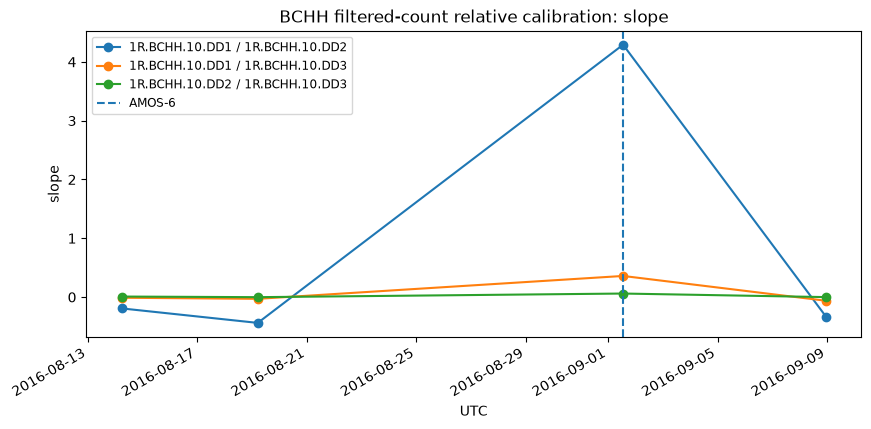

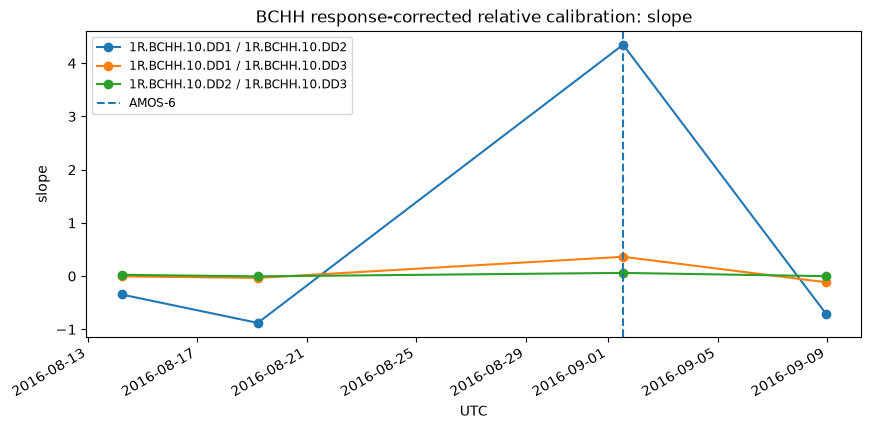

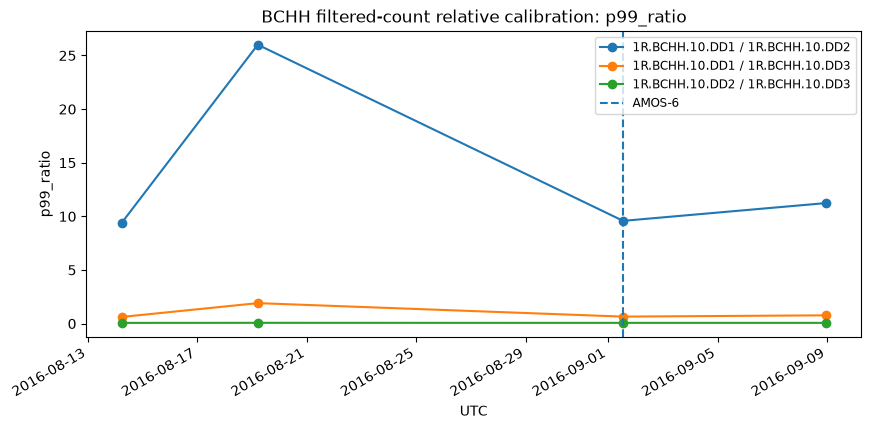

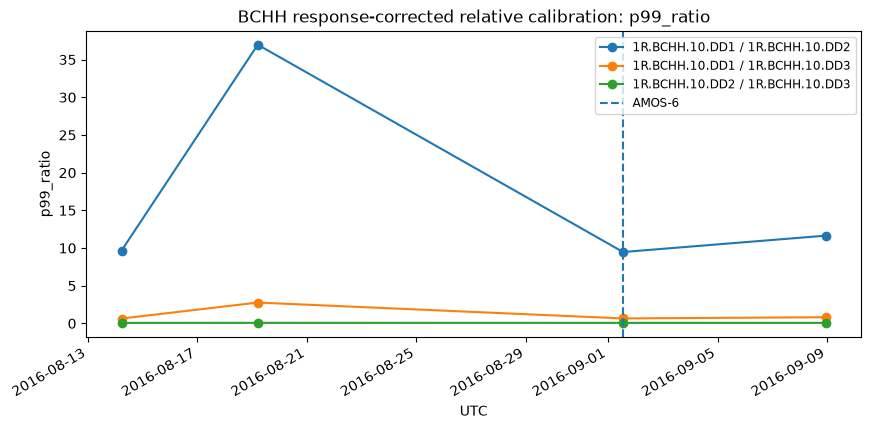

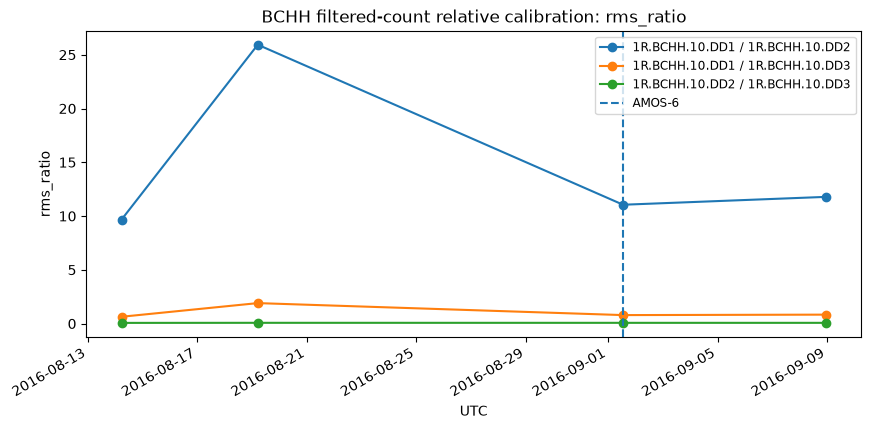

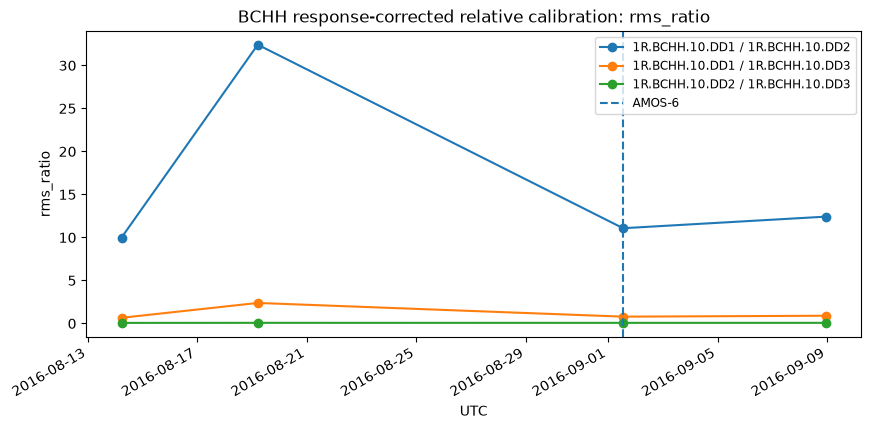

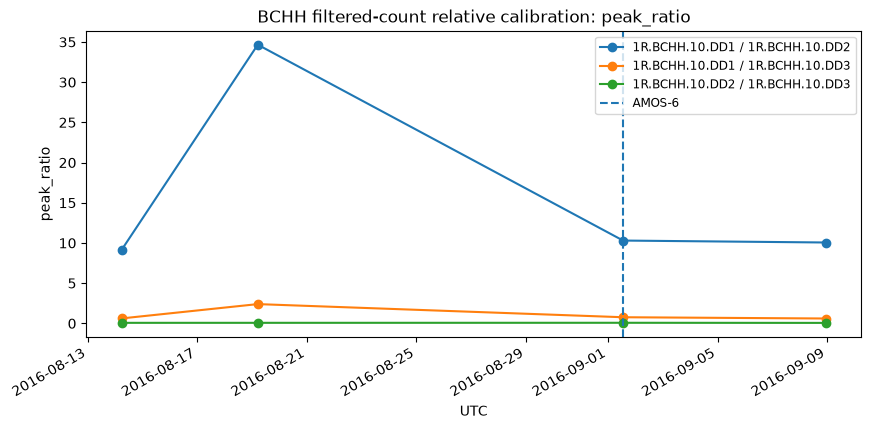

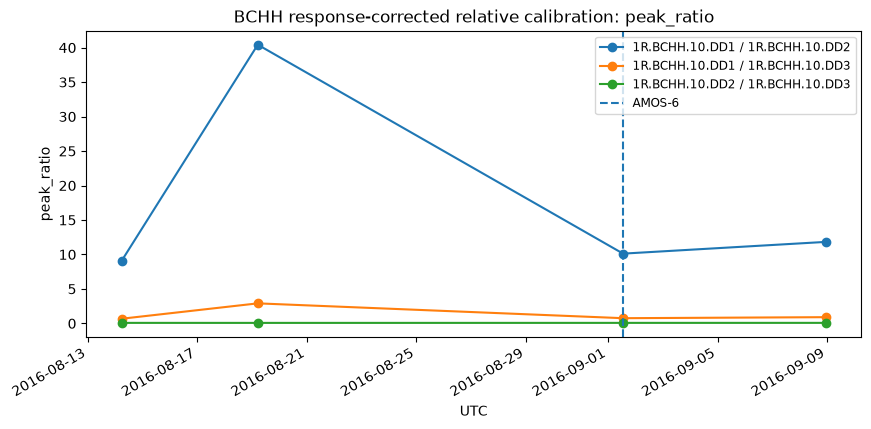

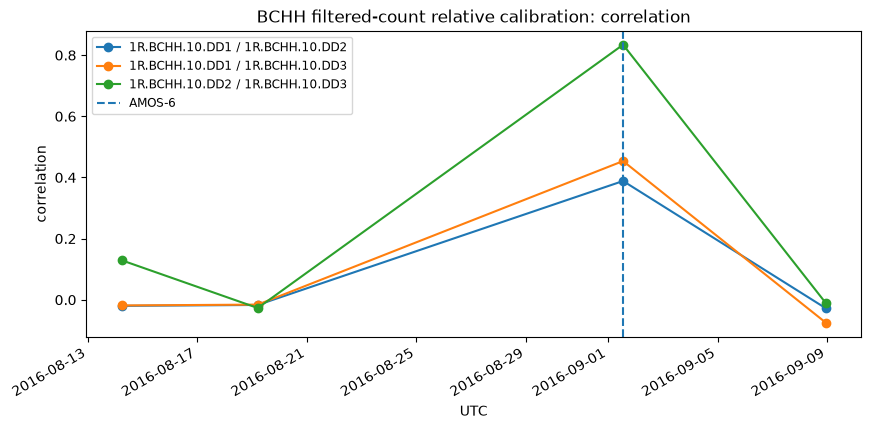

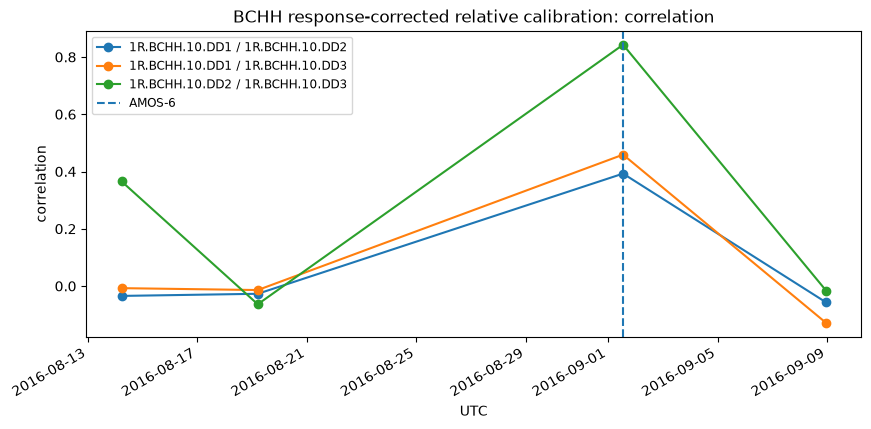

In [13]:
AMOS6_TIME = pd.to_datetime(events.loc[events.event_type.eq("pad_explosion"), "event_time_utc"].iloc[0], utc=True) if (events.event_type == "pad_explosion").any() else pd.Timestamp("2016-09-01T13:07:15Z")
def plot_metric(df,metric,title_prefix):
    if df.empty:return
    fig,ax=plt.subplots(figsize=(10,4.5))
    for pair,g in df.groupby("pair"):
        g=g.sort_values("event_time"); ax.plot(g.event_time,g[metric],marker="o",label=pair)
    ax.axvline(AMOS6_TIME,linestyle="--",label="AMOS-6")
    ax.set_ylabel(metric); ax.set_xlabel("UTC"); ax.set_title(f"{title_prefix}: {metric}"); ax.legend(fontsize="small")
    fig.autofmt_xdate(); plt.show()
for metric in ["slope","p99_ratio","rms_ratio","peak_ratio","correlation"]:
    plot_metric(raw_relative,metric,"BCHH filtered-count relative calibration")
    plot_metric(pa_relative,metric,"BCHH response-corrected relative calibration")


## 7. Interpretation / acceptance criteria

For the calibration conclusion, concentrate first on **JCSAT-16, AFSPC-6 and OSIRIS-REx**, whose launch times should have independent agreement in the reconciled catalog. Treat AMOS-6 separately as an extreme-amplitude survival/nonlinearity test.

Before accepting a calibration step:

- visually confirm the selected signal window on every event;
- require high inter-channel correlation in that window;
- inspect clipping, timing offsets and polarity;
- identify the sensor serial number behind each NSLC for each epoch;
- compare filtered-count ratios with response-corrected Pa ratios;
- if AMOS-6 is nonlinear or clipped, do not use its strongest interval to estimate gain;
- write any accepted calibration/QC conclusion back to channel-epoch metadata rather than hiding a correction in this notebook.


In [14]:
# Compact QC/result exports for comparison across notebook runs.
OUT = ROOT / "outputs/calibration_2016"
OUT.mkdir(parents=True, exist_ok=True)

if "signal_summary" in globals() and isinstance(signal_summary, pd.DataFrame):
    signal_summary.to_csv(OUT / "signal_window_qc.csv", index=False)
if "availability" in globals() and isinstance(availability, pd.DataFrame):
    availability.to_csv(OUT / "channel_availability.csv", index=False)
if "raw_relative" in globals() and isinstance(raw_relative, pd.DataFrame):
    raw_relative.to_csv(OUT / "relative_gain_filtered_counts.csv", index=False)
if "pa_relative" in globals() and isinstance(pa_relative, pd.DataFrame):
    pa_relative.to_csv(OUT / "relative_gain_response_corrected_pa.csv", index=False)
if "response_status" in globals() and isinstance(response_status, pd.DataFrame):
    response_status.to_csv(OUT / "response_correction_qc.csv", index=False)

print(f"Calibration outputs: {OUT}")


Calibration outputs: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/KSCRocketSeismology_event_catalog_workflow_v5/outputs/calibration_2016
